In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import fetch_daily_data
import os

# Load data

In [3]:
df_base = fetch_daily_data('SPY')
df_base

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains
Date,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.313034,1003200,0.0,0.0,0.0
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.485962,480500,0.0,0.0,0.0
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.537834,201300,0.0,0.0,0.0
1993-02-03,44.406250,44.843750,44.375000,44.812500,24.797235,529400,0.0,0.0,0.0
1993-02-04,44.968750,45.093750,44.468750,45.000000,24.900982,531500,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-10-09,673.530029,673.940002,669.210022,671.159973,671.159973,66501900,0.0,0.0,0.0
2025-10-10,672.130005,673.950012,652.840027,653.020020,653.020020,159422600,0.0,0.0,0.0
2025-10-13,660.650024,665.130005,659.770020,663.039978,663.039978,79560500,0.0,0.0,0.0


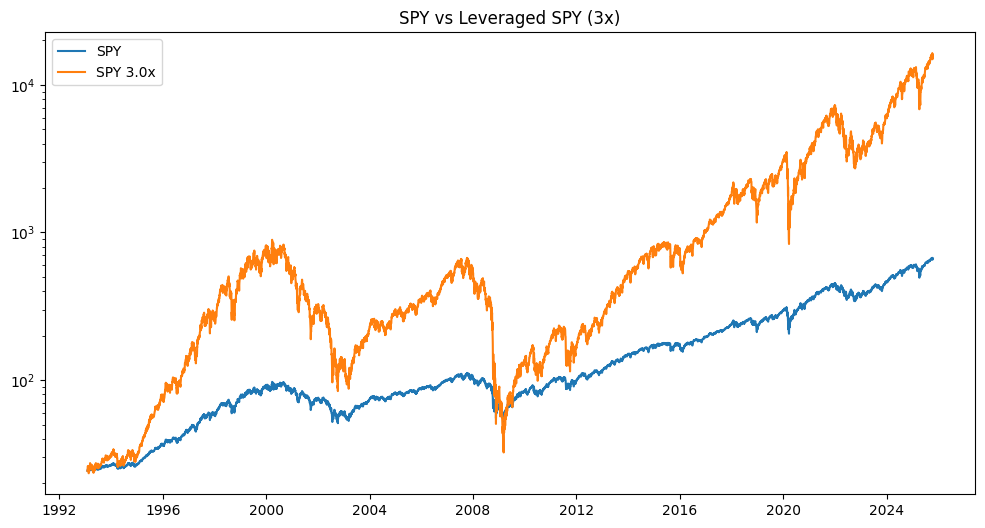

In [4]:
df_base['returns'] = df_base['adjclose'].pct_change() + 1
df_base['returns'] = df_base['returns'].fillna(1.0)
df_base['vol'] = df_base['returns'].rolling(window=21).std() * np.sqrt(252)
df_base['forward_vol'] = df_base['vol'].shift(-21)
df_base['forward_returns'] = df_base['returns'].rolling(21).apply(np.prod).shift(-21)
df_base

df_leveraged = df_base.copy()
leverage = 3.0
expense_ratio = 0.0045  # 0.45% annual expense ratio
df_leveraged['returns'] = (df_leveraged['returns'] - 1) * leverage + 1
df_leveraged['adjclose'] = df_base['adjclose'].iloc[0] * df_leveraged['returns'].cumprod()
df_leveraged['forward_returns'] = df_leveraged['returns'].rolling(21).apply(np.prod).shift(-21)
df_leveraged

plt.figure(figsize=(12, 6))
plt.plot(df_base['adjclose'], label='SPY')
plt.plot(df_leveraged['adjclose'], label=f'SPY {leverage}x')
plt.yscale('log')
plt.legend()
plt.title('SPY vs Leveraged SPY (3x)')
plt.show()

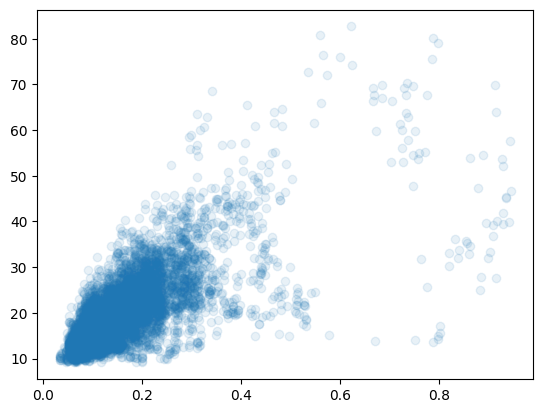

In [29]:
df_vix = fetch_daily_data('^VIX')
df_vix

df_base['vix'] = df_vix['adjclose']
plt.plot(df_base['forward_vol'], df_base['vix'], 'o', alpha=0.1)
plt.show()

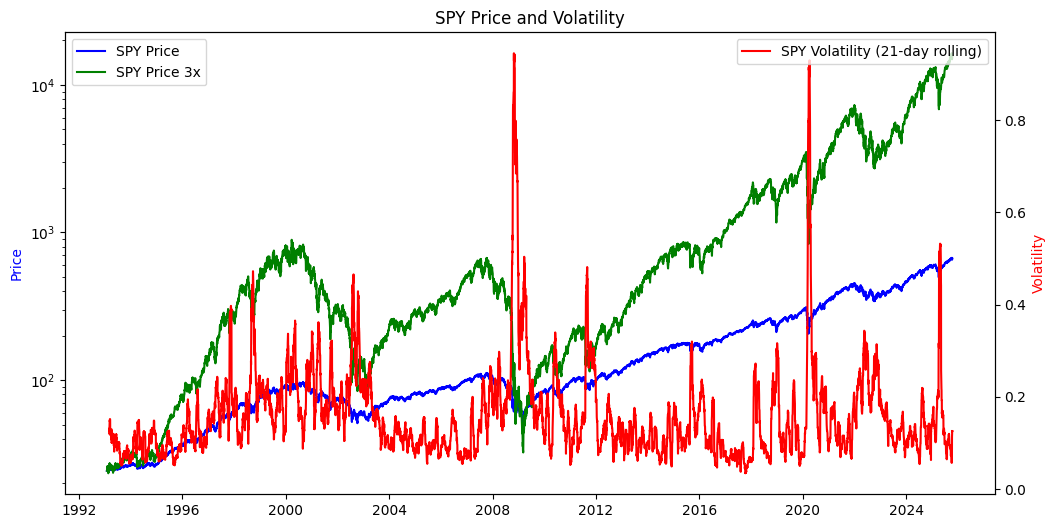

In [6]:


fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(df_base['adjclose'], color='blue', label='SPY Price')
ax1.plot(df_leveraged['adjclose'], color='green', label='SPY Price 3x')
ax2.plot(df_base['vol'], color='red', label='SPY Volatility (21-day rolling)')
ax1.set_yscale('log')
ax1.set_ylabel('Price', color='blue')
ax2.set_ylabel('Volatility', color='red')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('SPY Price and Volatility')
plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

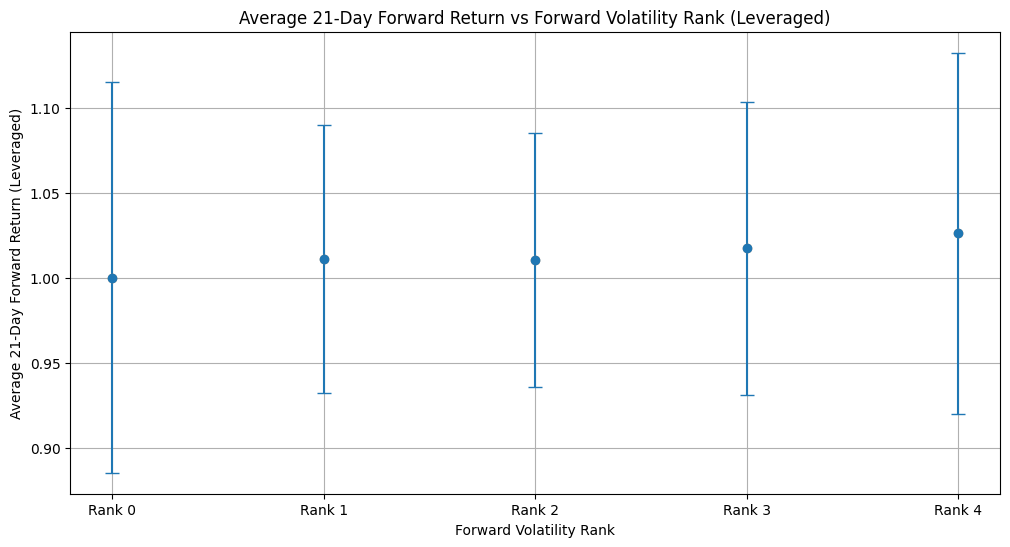

In [65]:


num_ranks = 5
df = pd.DataFrame()
df['base_returns'] = df_base['returns']
df['leveraged_returns'] = df_leveraged['returns']
df['forward_21d_base'] = df_base['forward_returns']
df['forward_21d_leveraged'] = df_leveraged['forward_returns'] / df['forward_21d_base']
df['past_returns_252d'] = df_base['returns'].rolling(252).apply(np.prod).shift(1)
df['past_returns_252d_lagged'] = df['past_returns_252d'].shift(21)
df['momentum'] = np.where(df['past_returns_252d_lagged'] > 1.0, 1, 0.01)
df['diff_21d'] = df['forward_21d_leveraged'] / df['forward_21d_base']
# df['forward_vol'] = df_base['forward_vol']
df['forward_vol'] = (df_base['vix']) * df['momentum']
# df['forward_vol'] = df_base['vol']
df['forward_vol_rank'] = pd.qcut(df['forward_vol'], q=num_ranks, labels=range(num_ranks))

df

avg_forward_21d_base = []
std_forward_21d_base = []
for rank in tqdm(range(num_ranks)):
    mask = df['forward_vol_rank'] == rank
    # avg_forward_21d_base.append(df.loc[mask, 'forward_21d_leveraged'].mean())
    avg_forward_21d_base.append(df.loc[mask, 'forward_21d_leveraged'].mean())
    std_forward_21d_base.append(df.loc[mask, 'forward_21d_leveraged'].std())

plt.figure(figsize=(12, 6))
plt.errorbar(range(num_ranks), avg_forward_21d_base, yerr=std_forward_21d_base, fmt='o', capsize=5)
plt.xticks(range(num_ranks), [f'Rank {i}' for i in range(num_ranks)])
plt.xlabel('Forward Volatility Rank')
plt.ylabel('Average 21-Day Forward Return (Leveraged)')
plt.title('Average 21-Day Forward Return vs Forward Volatility Rank (Leveraged)')
plt.grid()

plt.plot(range(num_ranks), avg_forward_21d_base, 'o', alpha=0.5)
plt.show()

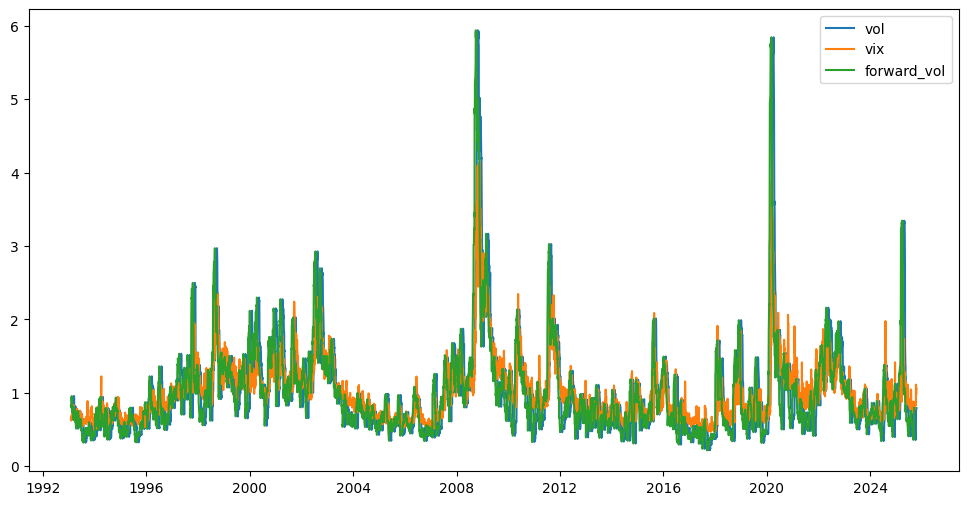

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(df_base['vol'] / df_base['vol'].mean(), label='vol')
plt.plot(df_base['vix'] / df_base['vix'].mean(), label='vix')
plt.plot(df_base['forward_vol'] / df_base['forward_vol'].mean(), label='forward_vol')
plt.legend()
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

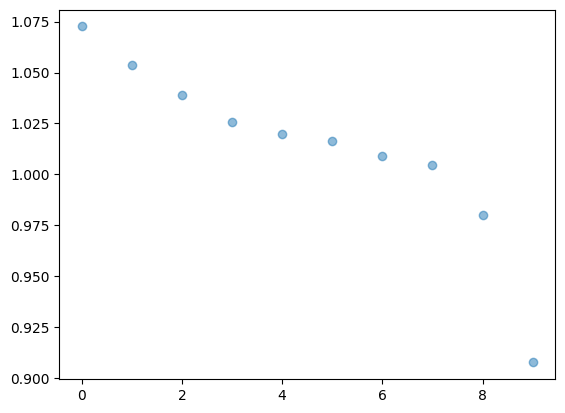

In [ ]:
for i, r in df.iterrows():
    if r['forward_vol_rank'] == 4:
        print(i, r['forward_vol'], r['forward_21d_base'], r['forward_21d_leveraged'], r['diff_21d'])